In [3]:
def solution(costs, budget):
    # 코드를 작성하세요.
    max_cost = -1
    for i in range(len(costs)):
        for j in range(i + 1, len(costs)):
            for k in range(j + 1, len(costs)):
                total_cost = costs[i] + costs[j] + costs[k]

            if total_cost > max_cost and total_cost <= budget:
                max_cost = total_cost
    
    return max_cost

print(solution([120, 80, 150, 60, 100], 300))

300


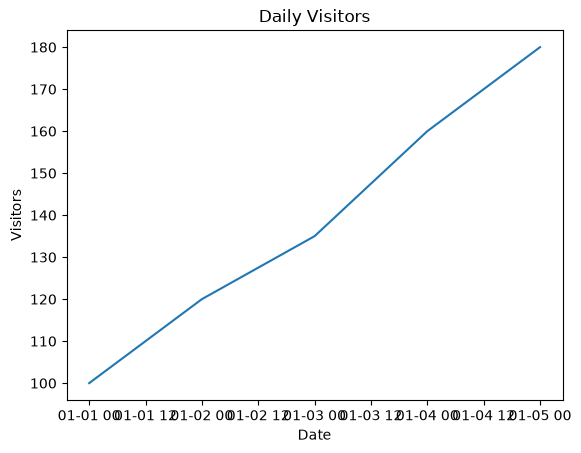

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
data = pd.DataFrame({
    "date": [
        "2026-01-05",
        "2026-01-01",
        "2026-01-04",
        "2026-01-02",
        "2026-01-03"
    ],
    "visitors": [180, 100, 160, 120, 135]
})

data['date'] = pd.to_datetime(data['date'])

data = data.sort_values("date")

plt.plot(data["date"], data["visitors"])

plt.xlabel("Date")
plt.ylabel("Visitors")
plt.title("Daily Visitors")

plt.show()

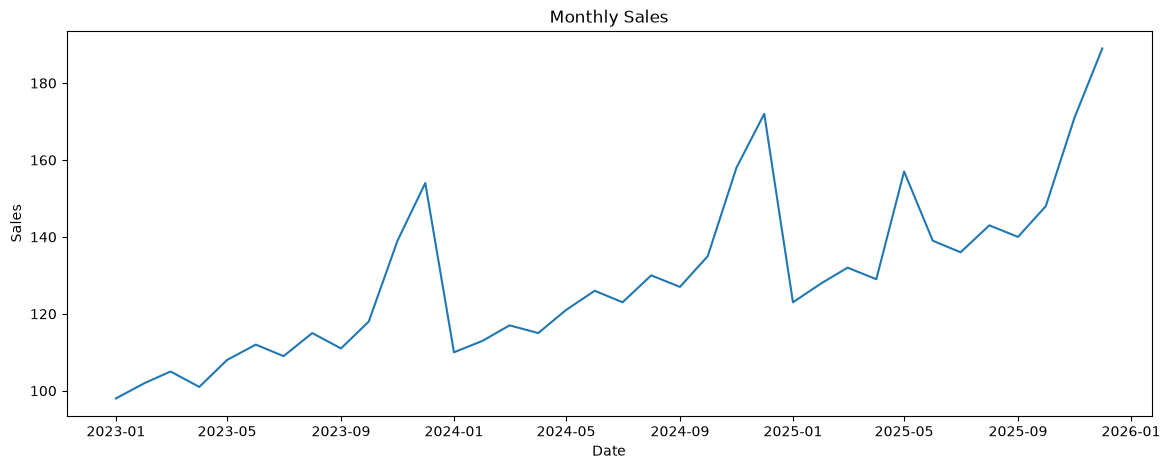

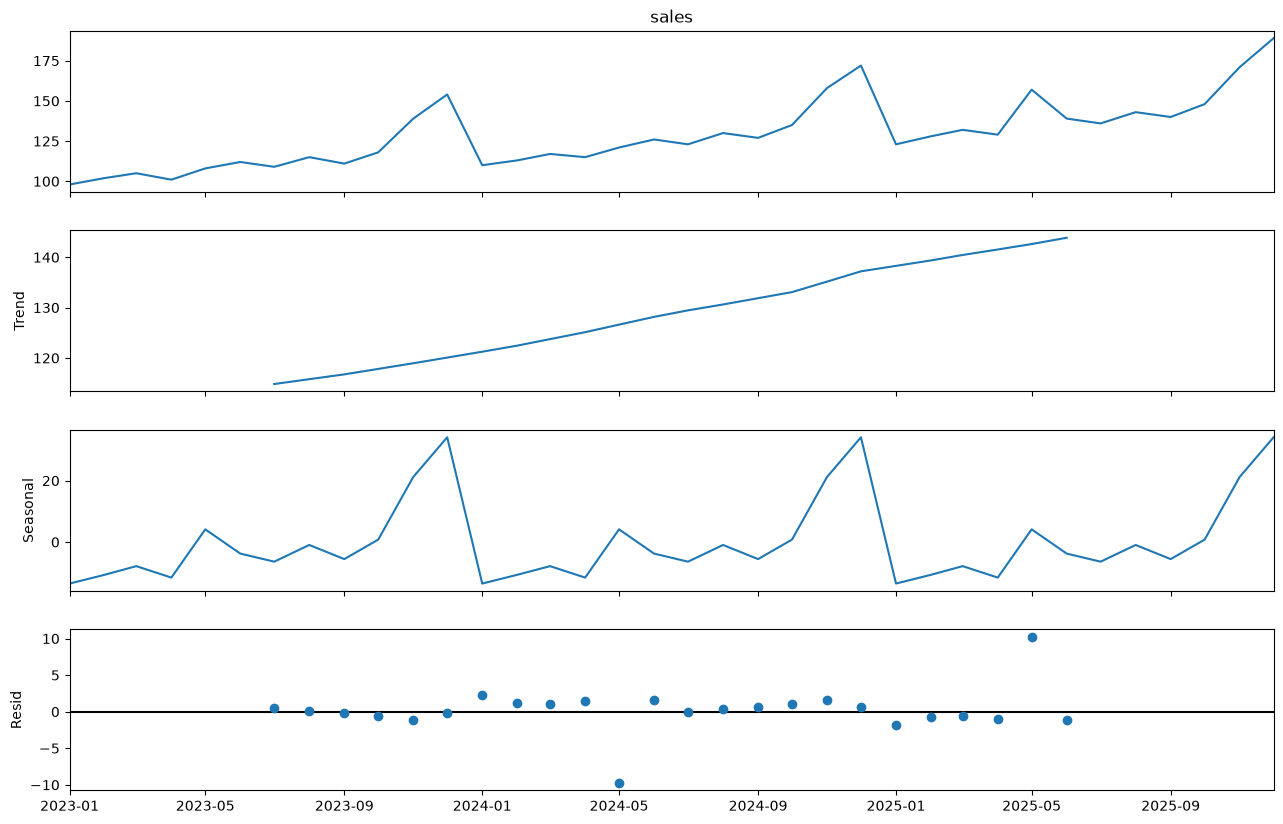

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

data = pd.DataFrame({
    "date": pd.date_range(
        start="2023-01-01",
        periods=36,
        freq="MS"
    ),
    "sales": [
        98, 102, 105, 101, 108, 112,
        109, 115, 111, 118, 139, 154,
        110, 113, 117, 115, 121, 126,
        123, 130, 127, 135, 158, 172,
        123, 128, 132, 129, 157, 139,
        136, 143, 140, 148, 171, 189
    ]
})

data = data.set_index("date")

# 원본 시계열 확인
plt.figure(figsize=(14, 5))

plt.plot(data.index, data["sales"])

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Monthly Sales")

plt.show()

# 시계열 분해
result = seasonal_decompose(
    data["sales"],
    model="additive",
    period=12
)

fig = result.plot()
fig.set_size_inches(14, 9)

plt.show()

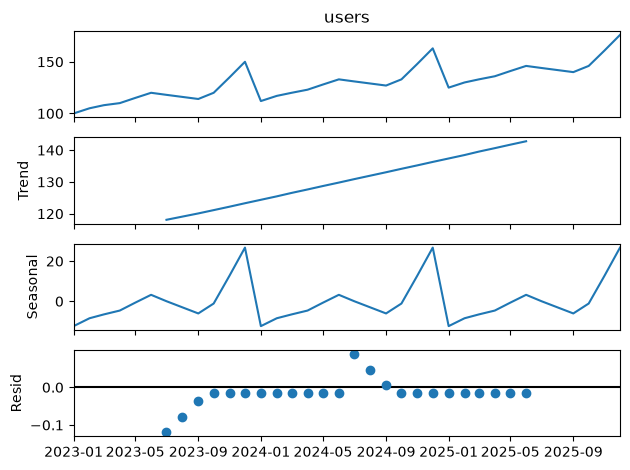

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose

data = pd.DataFrame({
    "date": pd.date_range(
        start="2023-01-01",
        periods=36,
        freq="MS"
    ),
    "users": [
        100, 105, 108, 110, 115, 120,
        118, 116, 114, 120, 135, 150,
        112, 117, 120, 123, 128, 133,
        131, 129, 127, 133, 148, 163,
        125, 130, 133, 136, 141, 146,
        144, 142, 140, 146, 161, 176
    ]
})

data = data.set_index("date")

result = seasonal_decompose(
    data["users"],
    model="additive",
    period=12
)

result.plot()
plt.show()

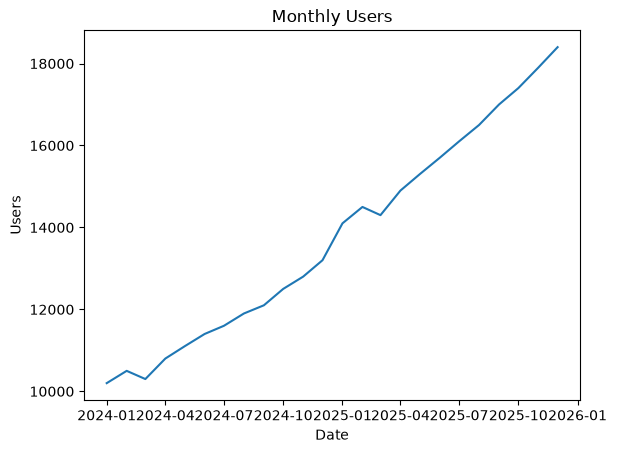

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.DataFrame({
    "date": pd.date_range(
        start="2024-01-01",
        periods=24,
        freq="MS"
    ),
    "users": [
        10200, 10500, 10300, 10800, 11100, 11400,
        11600, 11900, 12100, 12500, 12800, 13200,
        14100, 14500, 14300, 14900, 15300, 15700,
        16100, 16500, 17000, 17400, 17900, 18400
    ]
})

data = data.set_index("date")

plt.plot(data.index, data["users"])

plt.xlabel("Date")
plt.ylabel("Users")
plt.title("Monthly Users")

plt.show()

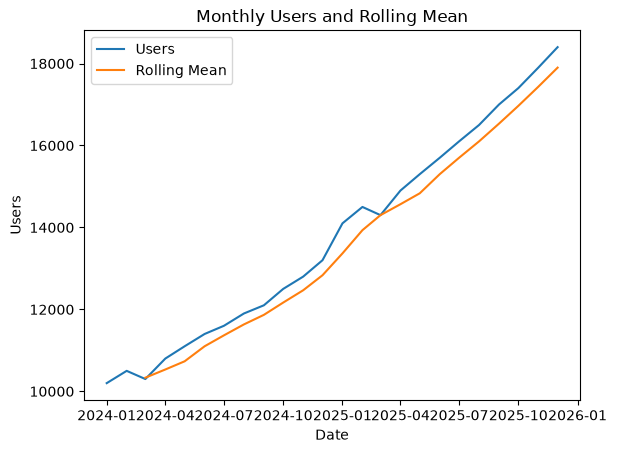

In [9]:
data["rolling_mean"] = data["users"].rolling(window=3).mean()

plt.plot(data.index, data["users"], label="Users")
plt.plot(data.index, data["rolling_mean"], label="Rolling Mean")

plt.xlabel("Date")
plt.ylabel("Users")
plt.title("Monthly Users and Rolling Mean")
plt.legend()

plt.show()

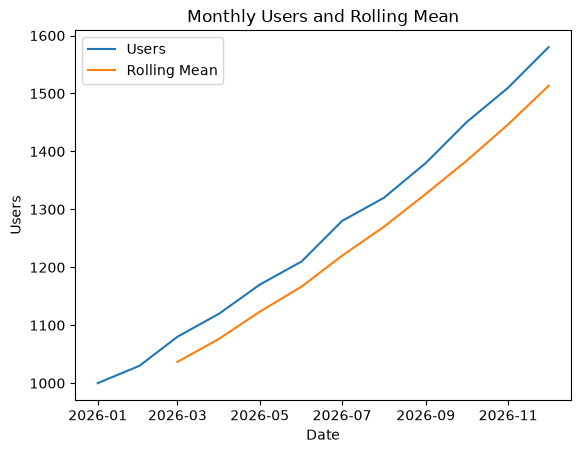

In [11]:
import pandas as pd

import matplotlib.pyplot as plt

data = pd.DataFrame({
    "date": pd.date_range(
        start="2026-01-01",
        periods=12,
        freq="MS"
    ),
    "users": [
        1000, 1030, 1080, 1120,
        1170, 1210, 1280, 1320,
        1380, 1450, 1510, 1580
    ]
})

data = data.set_index("date")

data["rolling_mean"] = data["users"].rolling(window=3).mean()

plt.plot(data.index, data["users"], label="Users")
plt.plot(data.index, data["rolling_mean"], label="Rolling Mean")

plt.xlabel("Date")
plt.ylabel("Users")
plt.title("Monthly Users and Rolling Mean")
plt.legend()

plt.show()

In [1]:
def solution(costs, budget):
    costs.sort()

    total_cost = 0
    count = 0

    for cost in costs:
        if total_cost + cost <= budget:
            total_cost += cost
            count += 1
        else:
            break

    return count

print(solution([2,5,1,3], 10))

# 버젯: 100 costs = [20, 30, 25, 40]

3


Train
2023-01-01 00:00:00 ~ 2025-06-01 00:00:00

Test
2025-07-01 00:00:00 ~ 2025-12-01 00:00:00


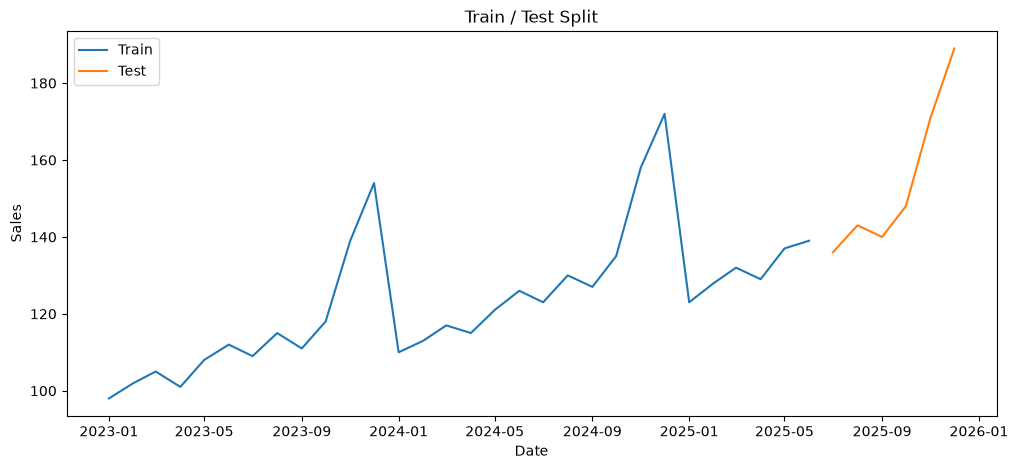

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 데이터 생성
data = pd.DataFrame({
    "date": pd.date_range(
        start="2023-01-01",
        periods=36,
        freq="MS"
    ),
    "sales": [
        98, 102, 105, 101, 108, 112,
        109, 115, 111, 118, 139, 154,
        110, 113, 117, 115, 121, 126,
        123, 130, 127, 135, 158, 172,
        123, 128, 132, 129, 137, 139,
        136, 143, 140, 148, 171, 189
    ]
})

# 날짜 순서대로 정렬하고 날짜를 인덱스로 설정
data = data.sort_values("date")
data = data.set_index("date")

# 마지막 6개월을 Test Data로 분리
train = data.iloc[:-6]
test = data.iloc[-6:]

# Train / Test 기간 확인
print("Train")
print(train.index.min(), "~", train.index.max())

print("\nTest")
print(test.index.min(), "~", test.index.max())

# Train / Test 시각화
plt.figure(figsize=(12, 5))

plt.plot(
    train.index,
    train["sales"],
    label="Train"
)

plt.plot(
    test.index,
    test["sales"],
    label="Test"
)

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Train / Test Split")
plt.legend()

plt.show()

                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                   30
Model:                 ARIMA(2, 1, 1)   Log Likelihood                -116.164
Date:                Wed, 30 Sep 2026   AIC                            240.327
Time:                        10:48:29   BIC                            245.796
Sample:                    01-01-2023   HQIC                           242.040
                         - 06-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3677      0.662      0.555      0.579      -0.930       1.666
ar.L2         -0.2373      0.603     -0.394      0.694      -1.419       0.944
ma.L1         -0.6793      0.566     -1.200      0.2

c:\MachineLearning-developed-MoonYoungheum\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\MachineLearning-developed-MoonYoungheum\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\MachineLearning-developed-MoonYoungheum\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


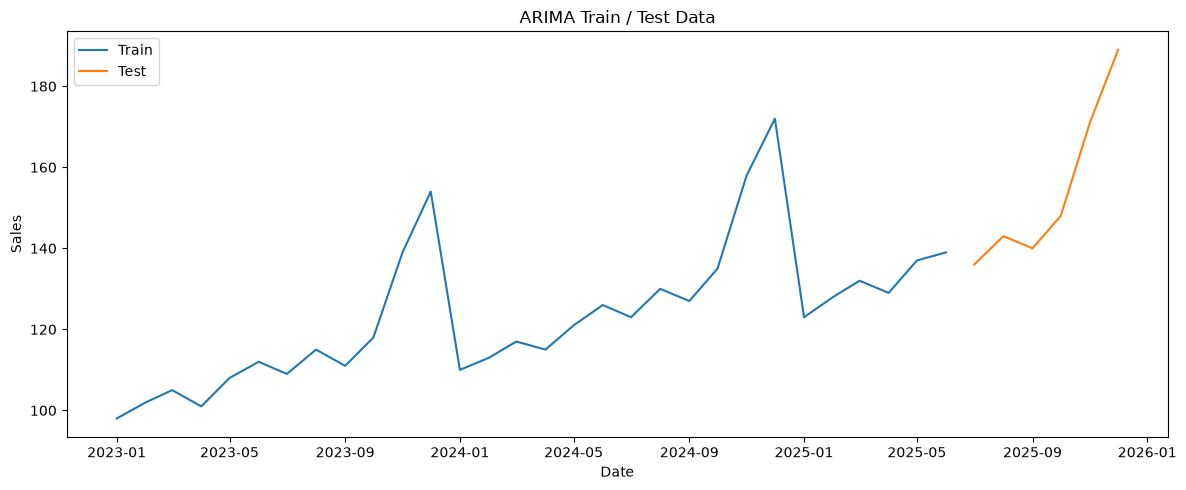

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# 데이터 생성
data = pd.DataFrame({
    "date": pd.date_range(
        start="2023-01-01",
        periods=36,
        freq="MS"
    ),
    "sales": [
        98, 102, 105, 101, 108, 112,
        109, 115, 111, 118, 139, 154,
        110, 113, 117, 115, 121, 126,
        123, 130, 127, 135, 158, 172,
        123, 128, 132, 129, 137, 139,
        136, 143, 140, 148, 171, 189
    ]
})

# 날짜 순서대로 정렬하고 인덱스로 설정
data = data.sort_values("date")
data = data.set_index("date")

# Train / Test 분리
train = data.iloc[:-6]
test = data.iloc[-6:]

# ARIMA(2, 1, 1) 모델 구조 설정
model = ARIMA(
    train["sales"],
    order=(2, 1, 1)
)

# Train Data를 이용하여 모델 학습
model_fit = model.fit()

# 학습 결과 확인
print(model_fit.summary())

# Train / Test 구간 시각화
plt.figure(figsize=(12, 5))

plt.plot(
    train.index,
    train["sales"],
    label="Train"
)

plt.plot(
    test.index,
    test["sales"],
    label="Test"
)

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("ARIMA Train / Test Data")
plt.legend()
plt.tight_layout()
plt.show()

            actual   predicted       lower       upper      error
2025-07-01     136  136.636946  110.832023  162.441869  -0.636946
2025-08-01     143  135.293311  103.963978  166.622645   7.706689
2025-09-01     140  135.360044  102.849023  167.871064   4.639956
2025-10-01     148  135.703471  102.392946  169.013996  12.296529
2025-11-01     171  135.813922  101.339302  170.288542  35.186078
2025-12-01     189  135.773032   99.926627  171.619438  53.226968


c:\MachineLearning-developed-MoonYoungheum\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\MachineLearning-developed-MoonYoungheum\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\MachineLearning-developed-MoonYoungheum\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


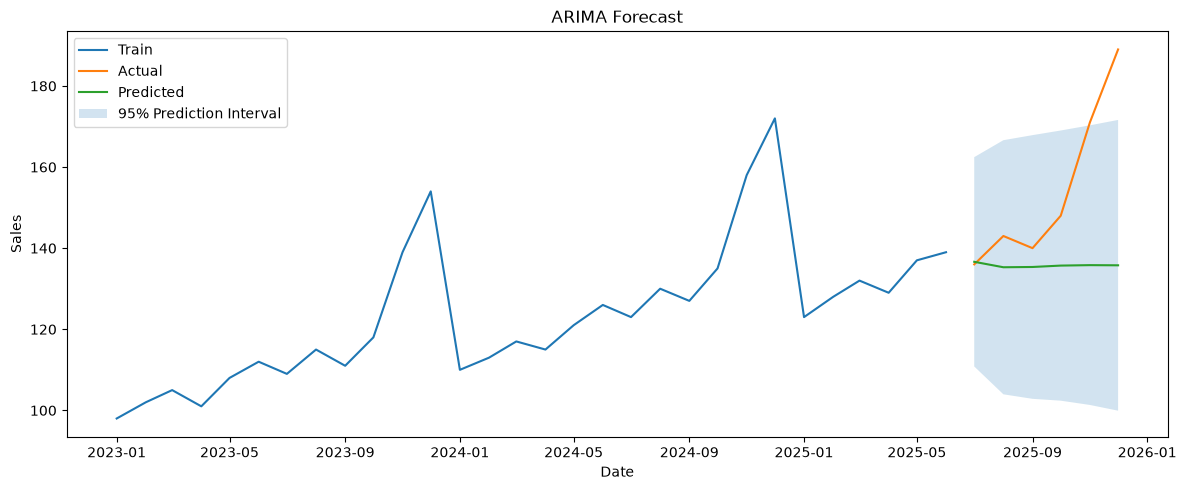

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# 데이터 생성
data = pd.DataFrame({
    "date": pd.date_range(
        start="2023-01-01",
        periods=36,
        freq="MS"
    ),
    "sales": [
        98, 102, 105, 101, 108, 112,
        109, 115, 111, 118, 139, 154,
        110, 113, 117, 115, 121, 126,
        123, 130, 127, 135, 158, 172,
        123, 128, 132, 129, 137, 139,
        136, 143, 140, 148, 171, 189
    ]
})

# 날짜 순서대로 정렬하고 인덱스로 설정
data = data.sort_values("date")
data = data.set_index("date")

# Train / Test 분리
train = data.iloc[:-6]
test = data.iloc[-6:]

# ARIMA 모델 학습
model = ARIMA(
    train["sales"],
    order=(2, 1, 1)
)

model_fit = model.fit()

# Test 기간만큼 미래 예측
forecast_result = model_fit.get_forecast(
    steps=len(test)
)

# 예측값
predicted = forecast_result.predicted_mean

# 95% Prediction Interval
prediction_interval = forecast_result.conf_int(
    alpha=0.05
)

# 실제값, 예측값, 예측 구간 정리
result = pd.DataFrame({
    "actual": test["sales"],
    "predicted": predicted,
    "lower": prediction_interval.iloc[:, 0],
    "upper": prediction_interval.iloc[:, 1]
})

# 예측 오차 계산
result["error"] = (
    result["actual"]
    - result["predicted"]
)

print(result)

# 실제값과 예측값 시각화
plt.figure(figsize=(12, 5))

plt.plot(
    train.index,
    train["sales"],
    label="Train"
)

plt.plot(
    test.index,
    test["sales"],
    label="Actual"
)

plt.plot(
    result.index,
    result["predicted"],
    label="Predicted"
)

plt.fill_between(
    result.index,
    result["lower"],
    result["upper"],
    alpha=0.2,
    label="95% Prediction Interval"
)

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("ARIMA Forecast")
plt.legend()
plt.tight_layout()
plt.show()

MAE: 18.95
RMSE: 26.78

예측 결과
            actual   predicted
date                          
2025-07-01     136  136.636946
2025-08-01     143  135.293311
2025-09-01     140  135.360044
2025-10-01     148  135.703471
2025-11-01     171  135.813922
2025-12-01     189  135.773032


c:\MachineLearning-developed-MoonYoungheum\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\MachineLearning-developed-MoonYoungheum\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\MachineLearning-developed-MoonYoungheum\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


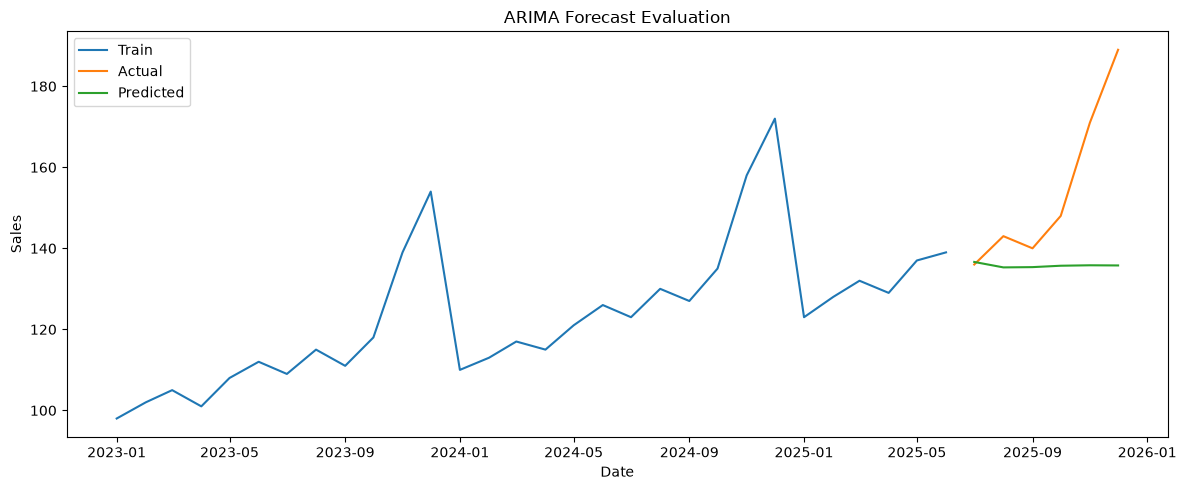

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 데이터 생성
data = pd.DataFrame({
    "date": pd.date_range(
        start="2023-01-01",
        periods=36,
        freq="MS"
    ),
    "sales": [
        98, 102, 105, 101, 108, 112,
        109, 115, 111, 118, 139, 154,
        110, 113, 117, 115, 121, 126,
        123, 130, 127, 135, 158, 172,
        123, 128, 132, 129, 137, 139,
        136, 143, 140, 148, 171, 189
    ]
})

# 날짜 순서대로 정렬하고 인덱스로 설정
data = data.sort_values("date")
data = data.set_index("date")

# Train / Test 분리
train = data.iloc[:-6]
test = data.iloc[-6:]

# ARIMA 모델 생성 및 학습
model = ARIMA(
    train["sales"],
    order=(2, 1, 1)
)

model_fit = model.fit()

# Test 기간 예측
forecast = model_fit.forecast(
    steps=len(test)
)

forecast.index = test.index

# MAE 계산
mae = mean_absolute_error(
    test["sales"],
    forecast
)

# RMSE 계산
rmse = mean_squared_error(
    test["sales"],
    forecast
) ** 0.5

# 평가 결과 출력
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

# 실제값과 예측값 정리
result = pd.DataFrame({
    "actual": test["sales"],
    "predicted": forecast
})

print("\n예측 결과")
print(result)

# 실제값과 예측값 시각화
plt.figure(figsize=(12, 5))

plt.plot(
    train.index,
    train["sales"],
    label="Train"
)

plt.plot(
    test.index,
    test["sales"],
    label="Actual"
)

plt.plot(
    forecast.index,
    forecast,
    label="Predicted"
)

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("ARIMA Forecast Evaluation")
plt.legend()
plt.tight_layout()
plt.show()